# Office Study Analysis Notebook
This notebook analyzes the offline pseudonymized data from the Office Study Group.

Sections covered:
1. **Data Loading & Preprocessing**
2. **User Level Analysis**: Engagement & System Interaction (Aggregate & Per-Question)
3. **Idea Progression**: Diversity, Intensity & Label Progression
4. **Final Decisions**: Outcomes & Consensus
5. **Post-Study Survey Stats**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import sys
from pathlib import Path

# Ensure the repository root is on sys.path so `tooling` is importable.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / "tooling").exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# Load data
csv_dir = _repo_root / "experiment_data" / "human_studies" / "office_study"
if not csv_dir.exists():
    csv_dir = (Path.cwd() / "../../../experiment_data/human_studies/office_study").resolve()

df_questions = pd.read_csv(f'{csv_dir}/questions.csv')
df_proposals = pd.read_csv(f'{csv_dir}/proposals.csv')
df_votes = pd.read_csv(f'{csv_dir}/proposal_votes.csv')
df_actions = pd.read_csv(f'{csv_dir}/action_logs.csv')
df_surveys = pd.read_csv(f'{csv_dir}/post_study_surveys.csv')

# Preprocess dates
df_actions['occurred_at'] = pd.to_datetime(df_actions['occurred_at'])
df_proposals['created'] = pd.to_datetime(df_proposals['created'])
df_votes['created'] = pd.to_datetime(df_votes['created'])

# Map question IDs to human-readable titles
q_map = dict(zip(df_questions['id'], df_questions['title']))
df_actions['question_title'] = df_actions['question'].map(q_map)
df_proposals['question_title'] = df_proposals['question'].map(q_map)
df_votes['question_title'] = df_votes['question'].map(q_map)

print(f"Loaded {len(df_questions)} questions, {len(df_proposals)} proposals, {len(df_actions)} actions.")


Loaded 3 questions, 27 proposals, 3169 actions.


## 2. User Level Analysis
### 2.1 Engagement (Activity over Time)
When are users active? We plot aggregate actions binned by day/hour.

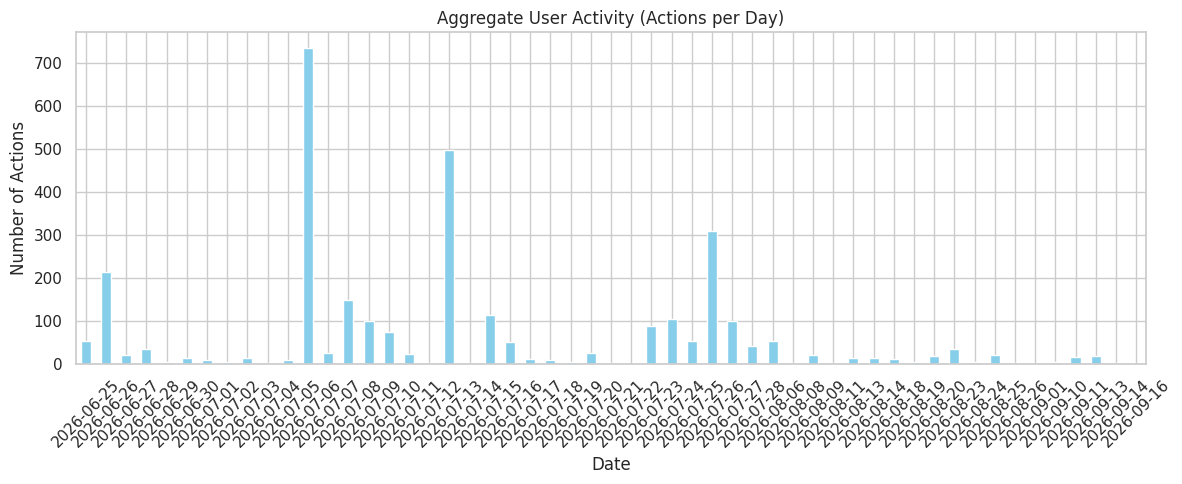

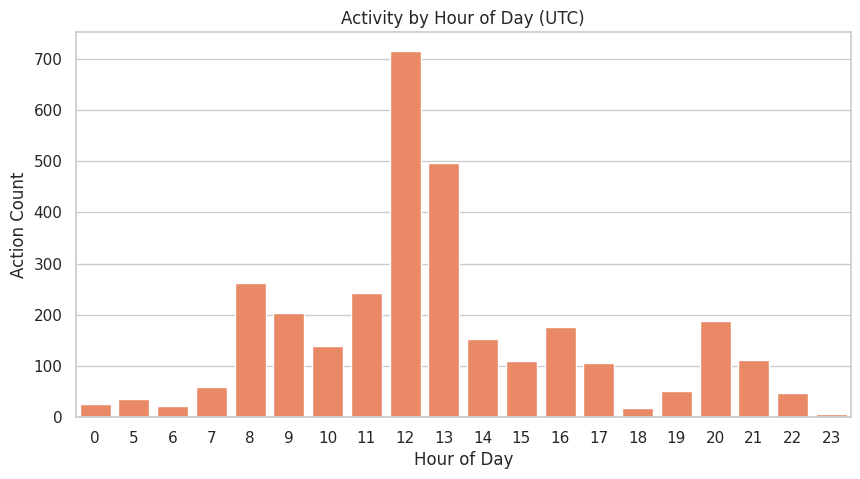

In [2]:
# Aggregate activity timeline
df_actions['date'] = df_actions['occurred_at'].dt.date
daily_actions = df_actions.groupby('date').size()

plt.figure(figsize=(12, 5))
daily_actions.plot(kind='bar', color='skyblue')
plt.title('Aggregate User Activity (Actions per Day)')
plt.ylabel('Number of Actions')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Activity by hour of day to see working hours
df_actions['hour'] = df_actions['occurred_at'].dt.hour
plt.figure(figsize=(10, 5))
sns.countplot(data=df_actions, x='hour', color='coral')
plt.title('Activity by Hour of Day (UTC)')
plt.xlabel('Hour of Day')
plt.ylabel('Action Count')
plt.show()


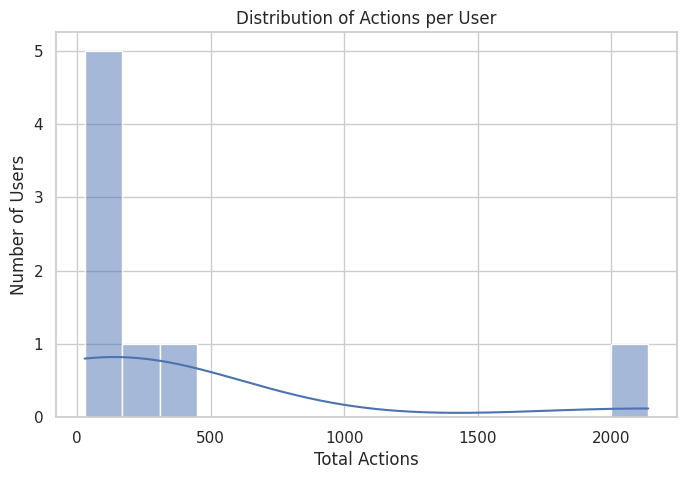

In [3]:
# Participation Distribution (Power users vs lurkers)
user_counts = df_actions['user'].value_counts()
plt.figure(figsize=(8, 5))
sns.histplot(user_counts, bins=15, kde=True)
plt.title('Distribution of Actions per User')
plt.xlabel('Total Actions')
plt.ylabel('Number of Users')
plt.show()


### 2.2 System Interaction
What are users doing? (Action types, voting vs proposing).

/tmp/ipykernel_114442/156042772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_actions, y='action_type', order=df_actions['action_type'].value_counts().index, palette='viridis')


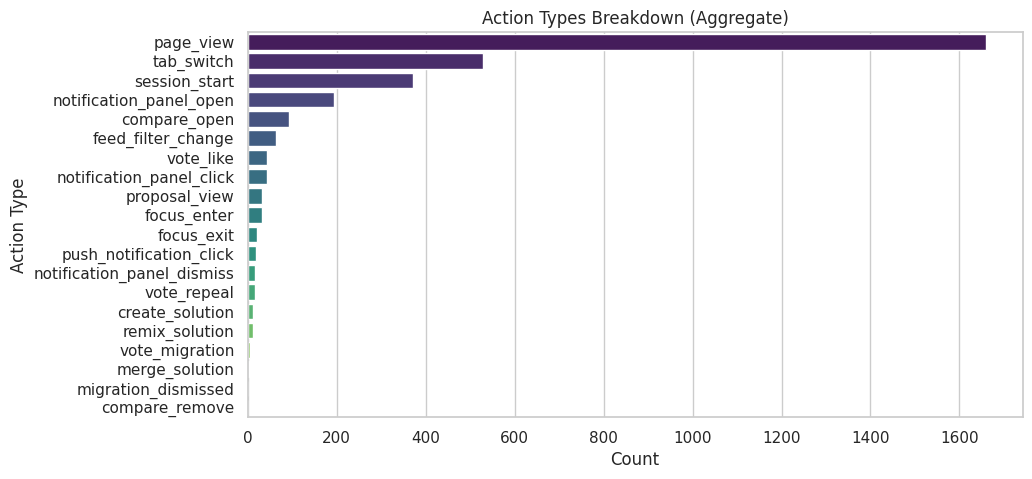

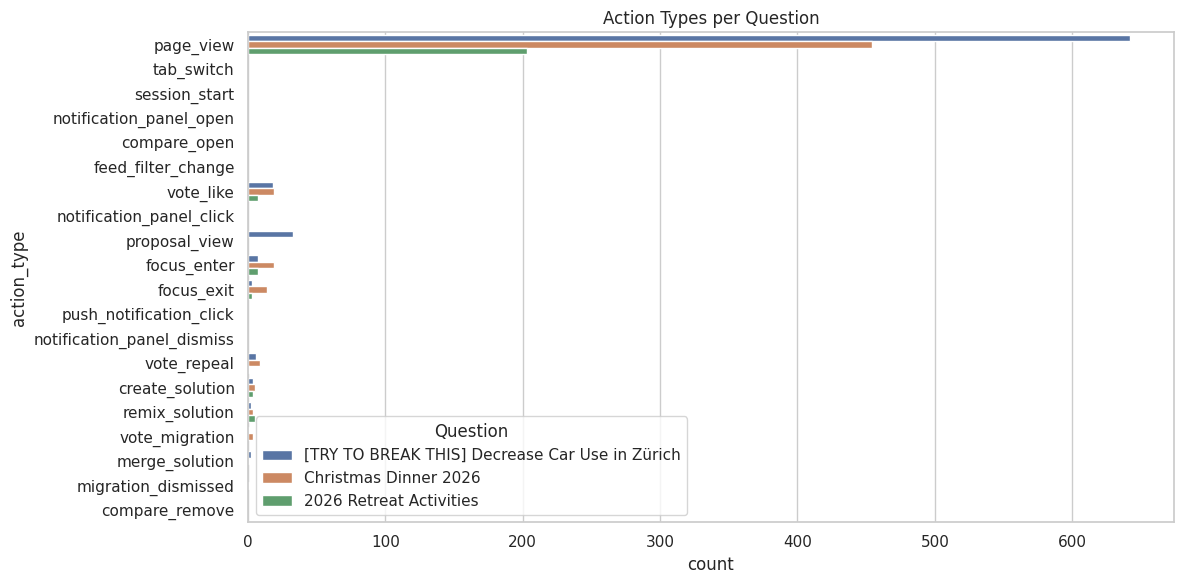

In [4]:
# Action Type Breakdown
plt.figure(figsize=(10, 5))
sns.countplot(data=df_actions, y='action_type', order=df_actions['action_type'].value_counts().index, palette='viridis')
plt.title('Action Types Breakdown (Aggregate)')
plt.xlabel('Count')
plt.ylabel('Action Type')
plt.show()

# Action breakdown per question
plt.figure(figsize=(12, 6))
sns.countplot(data=df_actions, y='action_type', hue='question_title', order=df_actions['action_type'].value_counts().index)
plt.title('Action Types per Question')
plt.legend(title='Question')
plt.tight_layout()
plt.show()


## 3. Idea Progression
### 3.1 Diversity and Velocity
How quickly were ideas generated across the different questions?

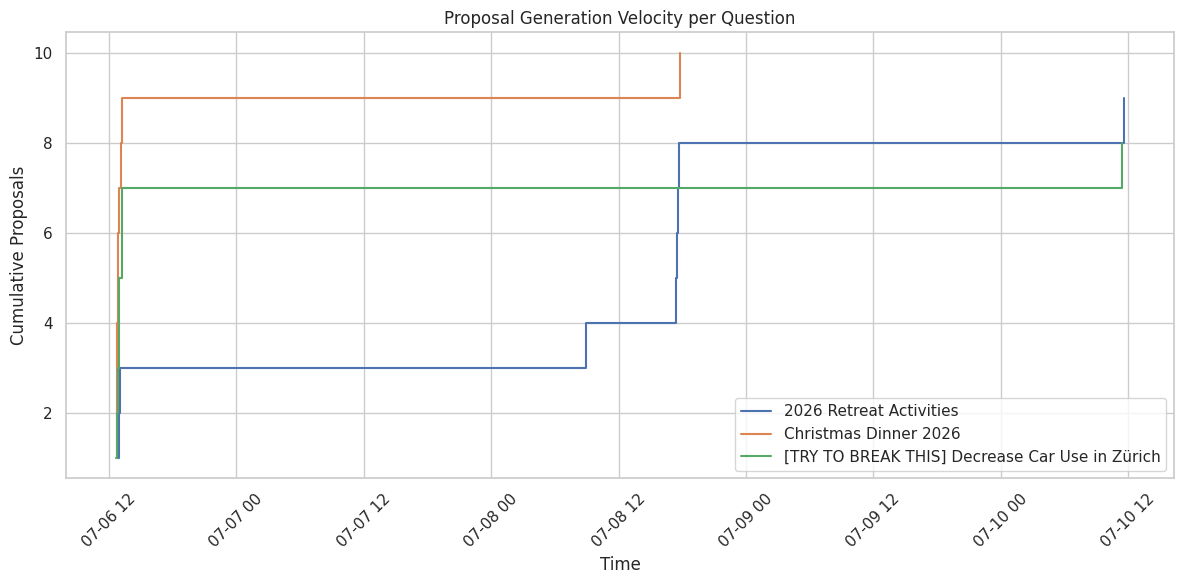

In [5]:
# Proposal generation over time (Velocity)
fig, ax = plt.subplots(figsize=(12, 6))

for q_id, group in df_proposals.groupby('question_title'):
    sorted_group = group.sort_values('created')
    sorted_group['cumulative_proposals'] = range(1, len(sorted_group) + 1)
    ax.step(sorted_group['created'], sorted_group['cumulative_proposals'], label=q_id, where='post')

plt.title('Proposal Generation Velocity per Question')
plt.xlabel('Time')
plt.ylabel('Cumulative Proposals')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Label Progression (Cluster Evolution)
How did the thematic clusters evolve as new ideas emerged?

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/nick/.local/lib/python3.14/site-packages/pandas/core/indexes/base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'cluster_key'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nick/.local/lib/python3.14/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykerne

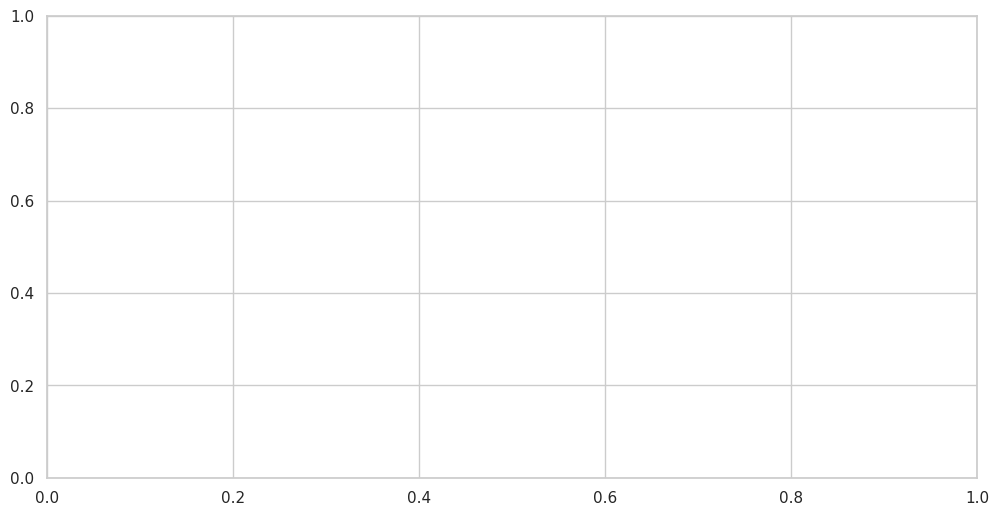

In [6]:
# Note: For strict temporal progression, we look at the cluster_key of proposals over time.
# Here we plot the number of distinct clusters over time per question.
fig, ax = plt.subplots(figsize=(12, 6))

for q_title, group in df_proposals.groupby('question_title'):
    sorted_group = group.sort_values('created')
    # cumulative unique clusters
    cumulative_clusters = [len(set(sorted_group['cluster_key'].iloc[:i+1])) for i in range(len(sorted_group))]
    ax.step(sorted_group['created'], cumulative_clusters, label=q_title, where='post')

plt.title('Thematic Cluster Evolution (Distinct Labels over Time)')
plt.xlabel('Time')
plt.ylabel('Cumulative Distinct Clusters')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Final Decisions
What were the final outcomes? Which solutions won (champions) and what was the consensus?

In [ ]:
# Extract Final Champions
champions = df_proposals[df_proposals['is_champion'] == True]

for q_title, group in champions.groupby('question_title'):
    print(f"\n{'='*50}")
    print(f"Question: {q_title}")
    print(f"Total Champions: {len(group)}")
    print(f"{'='*50}")
    
    for idx, row in group.iterrows():
        print(f" - [{row['support_count']} votes] {row['title']}")


## 5. Post-Study Survey Stats
Analyzing the subjective feedback from the participants.

In [ ]:
# Parse survey responses
survey_data = []
for _, row in df_surveys.iterrows():
    try:
        resp = json.loads(row['responses'])
        resp['user'] = row['user']
        survey_data.append(resp)
    except Exception as e:
        print(f"Error parsing survey {row['id']}: {e}")

if survey_data:
    df_resp = pd.DataFrame(survey_data)
    print(df_resp.head())
    
    # Example: If there's a 'satisfaction' or numerical column, we can plot it:
    numerical_cols = df_resp.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df_resp[col], kde=True)
        plt.title(f'Survey Response: {col}')
        plt.show()
else:
    print("No parseable survey responses found.")
